##1. Import Libraries
In this step, we import all required libraries for data processing, visualization, and predictive modeling.
Pandas and NumPy are used for data manipulation, Matplotlib and
Seaborn for visualization, and Scikit-learn for implementing machine learning models and evaluation metrics. Warnings are suppressed to ensure clean output.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")


##2. Load Dataset
Here, we load the cleaned Excel dataset prepared in Week 1.
We print the dataset shape to understand the number of rows and columns and preview the first few records to verify that the data has loaded correctly.

In [ ]:
# 2. LOAD DATASET
# -------------------------------
file_path = "Cleaned_Preprocessed_Dataset_Week1.xlsx"
df = pd.read_excel(file_path)

In [ ]:
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (8251, 30)


,Learner SignUp DateTime,Opportunity Id,Opportunity Name,Opportunity Category,Opportunity End Date,First Name,Date of Birth,Gender,Country,Institution Name,...,Apply_Quarter,Apply_Day_of_Week,Apply_Week_of_Year,Opportunity_Duration_Days,Days_Until_Opportunity_Start,Application_Accepted,Country_Group,Opportunity_Popularity,Apply_Season,Is_Weekend
0,2023-06-14 12:30:35,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Faria,2001-12-01,Female,Pakistan,Nwihs,...,2,Wednesday,24,841.015278,-459.753819,1,Pakistan,1385,Summer,0
1,2023-01-05 05:29:16,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Poojitha,2000-08-16,Female,India,Saint Louis University,...,1,Thursday,1,841.015278,-299.484514,1,India,1385,Winter,0
2,2023-08-29 05:20:03,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Amrutha Varshini,1999-01-11,Female,United States,Saint Louis University,...,3,Sunday,36,841.015278,-548.147257,1,United States,1385,Fall,1
3,2023-06-01 15:26:36,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Vinay Varshith,2000-04-19,Male,United States,Saint Louis University,...,2,Thursday,22,841.015278,-446.881609,1,United States,1385,Summer,0
4,2024-02-03 19:16:07,00000000-0GN2-A0AY-7XK8-C5FZPP,Career Essentials: Getting Started with Your P...,Course,2024-06-29 18:52:39,Mor,1996-12-05,Male,India,Saint Louis University,...,1,Saturday,5,841.015278,-446.881609,0,India,1385,Winter,1


##3. Data Preparation & Feature Engineering
In this section, we prepare the dataset for time-series forecasting:

Convert the learner sign-up timestamp into datetime format.

Extract Year-Month to aggregate application counts monthly.

Group the data to calculate total applications per month.

Create additional predictive features:

Month (seasonality effect)

Year (long-term trend)

Time_Index (captures growth progression over time)

These engineered features help improve the model’s ability to detect patterns and trends.

In [ ]:
# Convert to datetime
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'])

# Extract Year-Month
df['YearMonth'] = df['Learner SignUp DateTime'].dt.to_period('M')

# Aggregate monthly application counts
monthly_data = df.groupby('YearMonth').size().reset_index(name='Applications')

# Convert period back to timestamp
monthly_data['YearMonth'] = monthly_data['YearMonth'].dt.to_timestamp()

# Create additional features
monthly_data['Month'] = monthly_data['YearMonth'].dt.month
monthly_data['Year'] = monthly_data['YearMonth'].dt.year
monthly_data['Time_Index'] = np.arange(len(monthly_data))

monthly_data.head()


,YearMonth,Applications,Month,Year,Time_Index
0,2023-01-01,176,1,2023,0
1,2023-02-01,179,2,2023,1
2,2023-03-01,265,3,2023,2
3,2023-04-01,353,4,2023,3
4,2023-05-01,494,5,2023,4


##4. Train-Test Split (Time-Based Split)
Since this is time-series data, we split the dataset chronologically instead of randomly.
The first 75% of observations are used for training the model, while the remaining 25% are used for testing.

This prevents future data leakage and ensures realistic forecasting evaluation.

In [ ]:
train_size = int(len(monthly_data) * 0.75)

train = monthly_data.iloc[:train_size]
test = monthly_data.iloc[train_size:]

X_train = train[['Month', 'Year', 'Time_Index']]
y_train = train['Applications']

X_test = test[['Month', 'Year', 'Time_Index']]
y_test = test['Applications']


##5. Linear Regression Model
In this step, we implement a Linear Regression model to forecast application counts.
This model assumes a linear relationship between the independent variables (Month, Year, Time_Index) and the target variable (Applications).

It helps capture general growth trends and basic seasonal patterns.

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)


##6. Random Forest Model
Here, we implement a Random Forest Regressor, which is a tree-based ensemble model.

Unlike linear regression, Random Forest can capture nonlinear relationships and complex patterns in the data. It is generally more flexible and robust for forecasting tasks involving fluctuations.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

##7. Model Evaluation Function
We define a reusable evaluation function to assess model performance using the following metrics:

RMSE (Root Mean Squared Error) – measures prediction error magnitude

MAE (Mean Absolute Error) – average absolute prediction error

MAPE (Mean Absolute Percentage Error) – percentage error

R² Score – indicates how well the model explains variability

These metrics help compare model accuracy objectively.

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n--- {model_name} Performance ---")
    print("RMSE:", round(rmse, 2))
    print("MAE:", round(mae, 2))
    print("MAPE:", round(mape, 2), "%")
    print("R2:", round(r2, 2))

    return rmse, mae, mape, r2


lr_metrics = evaluate_model(y_test, lr_preds, "Linear Regression")
rf_metrics = evaluate_model(y_test, rf_preds, "Random Forest")


--- Linear Regression Performance ---
RMSE: 281.93
MAE: 278.31
MAPE: 295.58 %
R2: -63.0

--- Random Forest Performance ---
RMSE: 75.46
MAE: 70.14
MAPE: 78.56 %
R2: -3.59


##8. Model Comparison Table
This section creates a comparison table to evaluate both models side by side.

By comparing RMSE, MAE, MAPE, and R², we can identify which model performs better and select the most reliable forecasting approach.

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [lr_metrics[0], rf_metrics[0]],
    "MAE": [lr_metrics[1], rf_metrics[1]],
    "MAPE": [lr_metrics[2], rf_metrics[2]],
    "R2": [lr_metrics[3], rf_metrics[3]]
})

print("\nModel Comparison:")
comparison



Model Comparison:


,Model,RMSE,MAE,MAPE,R2
0,Linear Regression,281.927402,278.312500,295.579907,-63.001748
1,Random Forest,75.460438,70.139167,78.555316,-3.585175


##9. Actual vs Predicted Visualization
This visualization compares actual application counts with the model’s predicted values.

It provides a visual assessment of prediction accuracy and shows how closely the model follows real trends.

This is essential for communicating results to stakeholders.

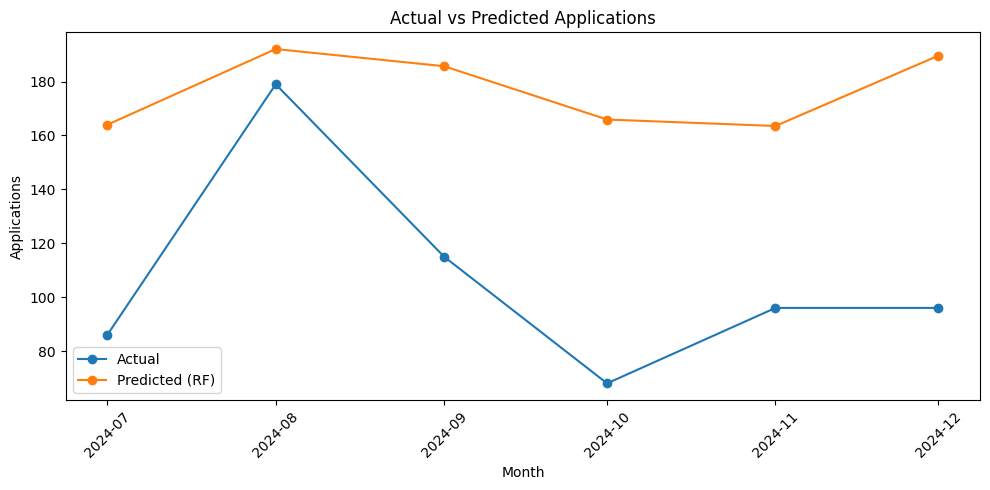

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(test['YearMonth'], y_test, label="Actual", marker='o')
plt.plot(test['YearMonth'], rf_preds, label="Predicted (RF)", marker='o')
plt.title("Actual vs Predicted Applications")
plt.xlabel("Month")
plt.ylabel("Applications")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Feature Importance:
      Feature  Importance
2  Time_Index    0.682654
0       Month    0.292672
1        Year    0.024674


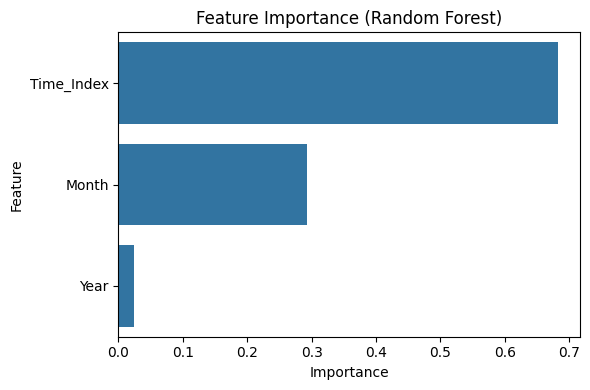

In [ ]:
importances = rf_model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(6,4))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()


##11. Forecast Next 3 Months
In this step, we generate forecasts for the next three months.

We:

Create future time periods.

Generate corresponding feature values.

Use the trained Random Forest model to predict future application counts.

This simulates real-world forecasting and supports forward-looking decision-making.

In [ ]:
future_periods = 3
last_index = monthly_data['Time_Index'].iloc[-1]
last_date = monthly_data['YearMonth'].iloc[-1]

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=future_periods,
    freq='MS'
)

future_df = pd.DataFrame({
    "YearMonth": future_dates
})

future_df['Month'] = future_df['YearMonth'].dt.month
future_df['Year'] = future_df['YearMonth'].dt.year
future_df['Time_Index'] = np.arange(last_index + 1, last_index + 1 + future_periods)

##12. Forecast Visualization
This final visualization combines historical data and predicted future values.

It clearly shows projected application trends and helps stakeholders understand upcoming demand patterns for planning and resource allocation.

In [ ]:
future_predictions = rf_model.predict(
    future_df[['Month', 'Year', 'Time_Index']]
)

future_df['Predicted_Applications'] = future_predictions

print("\nNext 3 Month Forecast:")
print(future_df)



Next 3 Month Forecast:
   YearMonth  Month  Year  Time_Index  Predicted_Applications
0 2025-01-01      1  2025          24                 152.555
1 2025-02-01      2  2025          25                 134.115
2 2025-03-01      3  2025          26                 121.970


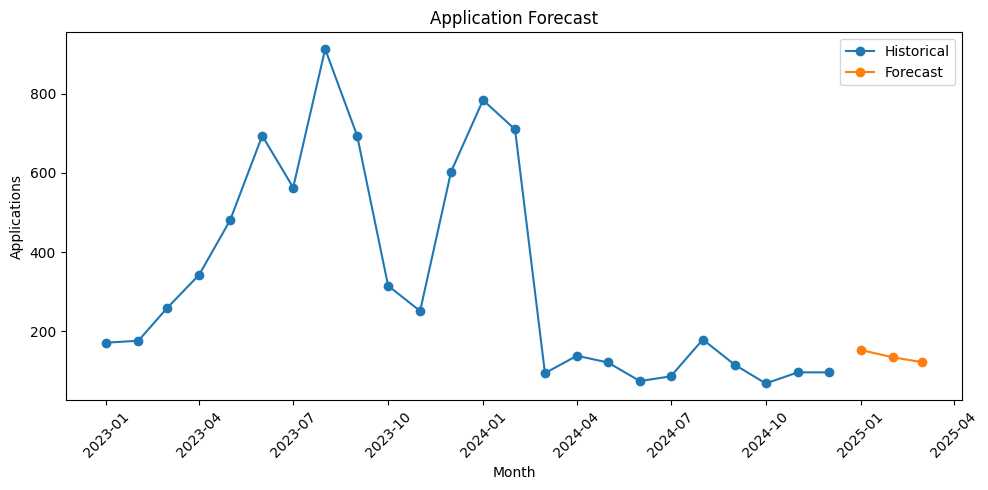

In [ ]:

plt.figure(figsize=(10,5))
plt.plot(monthly_data['YearMonth'], monthly_data['Applications'], label="Historical", marker='o')
plt.plot(future_df['YearMonth'], future_df['Predicted_Applications'], label="Forecast", marker='o')
plt.title("Application Forecast")
plt.xlabel("Month")
plt.ylabel("Applications")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
